In [ ]:
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 30.8 MB/s eta 0:00:00


## Mount Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


## Linke to my Work Directory mounted on MyDrive

In [ ]:
import os

BASE_FOLDER = "/content/drive/MyDrive/Sphinx_Project"
os.makedirs(BASE_FOLDER, exist_ok=True)

print(f"Folder creado: {BASE_FOLDER}")

Folder creado: /content/drive/MyDrive/Sphinx_Project


## Check Harware before Start Up

In [ ]:
import subprocess
result = subprocess.run(
    ['nvidia-smi', '--query-gpu=name,memory.total,driver_version',
     '--format=csv,noheader'],
    capture_output=True, text=True
)
print('GPU INFO:')
print(result.stdout)

if 'A100' in result.stdout:
    print('✓ A100 confirmed — batch=128 is safe')
elif 'L4' in result.stdout:
    print('⚠ L4 assigned — change batch to 32')
elif 'T4' in result.stdout:
    print('⚠ T4 assigned — change batch to 16')
else:
    print('⚠ Unknown GPU — start with batch=16')

GPU INFO:
NVIDIA A100-SXM4-40GB, 40960 MiB, 580.82.07

✓ A100 confirmed — batch=128 is safe


In [ ]:
import torch

In [ ]:
print("GPU:", torch.cuda.get_device_name(0))
print("VRAM (GB):", torch.cuda.get_device_properties(0).total_memory / 1e9)

GPU: NVIDIA A100-SXM4-40GB
VRAM (GB): 42.405855232


In [ ]:
import subprocess, sys

In [ ]:
# Validate GPU Hardware
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout)

Mon May  4 21:59:28 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   31C    P0             44W /  400W |       6MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

## Monitor outputs and logs on WandDB

In [ ]:
! pip install wandb -q

In [ ]:
import wandb
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 wandb_v1_GXwHD1hcykVDeHwXXGLVyhRVzwe


wandb: WARNING Invalid choice
wandb: Enter your choice:

 wandb_v1_GXwHD1hcykVDeHwXXGLVyhRVzwe


wandb: WARNING Invalid choice
wandb: Enter your choice:

...

wandb: WARNING Invalid choice
wandb: Enter your choice:

 wandb_v1_FXzC6bLOhDha6cRS74JUNz


wandb: WARNING Invalid choice
wandb: Enter your choice:

 FXzC6bLOhDha6cRS74JUNzPyqpw_dePbDME4vIINcHMSUKsoXf7H3jm6mal4UUo2FmRxOPG0Gcpe8


wandb: WARNING Invalid choice
wandb: Enter your choice:

KeyboardInterrupt



##  Check  Device and Ultralytics Version

In [ ]:
import ultralytics, torch

In [ ]:
print(f'Ultralytics : {ultralytics.__version__}')
print(f'PyTorch     : {torch.__version__}')
print(f'CUDA        : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'Device      : {torch.cuda.get_device_name(0)}')
    vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'VRAM        : {vram:.1f} GB')

Ultralytics : 8.4.46
PyTorch     : 2.10.0+cu128
CUDA        : True
Device      : NVIDIA A100-SXM4-40GB
VRAM        : 42.4 GB


## Extract Dataset from MyDrive

In [ ]:
ZIP_PATH = '/content/drive/MyDrive/datasetv2.zip'

In [ ]:
if os.path.exists(ZIP_PATH):
    size_gb = os.path.getsize(ZIP_PATH) / 1e9
    print(f'✓ Found: {ZIP_PATH} ({size_gb:.2f} GB)')
else:
    print(f'✗ NOT FOUND: {ZIP_PATH}')
    print('Adjust ZIP_PATH to match your Drive location')

✓ Found: /content/drive/MyDrive/SphinxEyes_v1.zip (1.29 GB)


In [ ]:
print('Extracting... (2-3 min for 1.3 GB)')
!unzip -q "{ZIP_PATH}" -d /content/


Extracting... (2-3 min for 1.3 GB)


In [ ]:
print('\nStructure:')
!ls /content/SphinxEyes_v1/
print('\nImages train:')
!ls /content/SphinxEyes_v1/images/train/ | wc -l
print('Images val:')
!ls /content/SphinxEyes_v1/images/val/ | wc -l
print('Labels train:')
!ls /content/SphinxEyes_v1/labels/train/ | wc -l
print('Labels val:')
!ls /content/SphinxEyes_v1/labels/val/ | wc -l


Structure:
class_map.json	dataset.yaml  images  labels

Images train:
19398
Images val:
4777
Labels train:
19216
Labels val:
4768


In [ ]:
import yaml, json, random
from pathlib import Path

In [ ]:
DATASET_YAML = '/content/SphinxEyes_v1/dataset.yaml'

In [ ]:
with open(DATASET_YAML) as f:
    cfg = yaml.safe_load(f)

In [ ]:
print(f'Classes (nc) : {cfg["nc"]}')
print(f'Train        : {cfg["train"]}')
print(f'Val          : {cfg["val"]}')


Classes (nc) : 145
Train        : images/train
Val          : images/val


In [ ]:
print(f'\nFirst 10 classes:')
for i, name in enumerate(cfg['names'][:10]):
    print(f'  {i:3d}: {name}')
print(f'\nLast 5 classes:')
for i, name in enumerate(cfg['names'][-5:]):
    print(f'  {cfg["nc"]-5+i:3d}: {name}')


First 10 classes:
    0: Aa15
    1: a1
    2: a2
    3: a24
    4: a30
    5: a40
    6: a42
    7: a50
    8: b1
    9: cartouche

Last 5 classes:
  140: z1
  141: z2
  142: z3
  143: z4
  144: z11


## Confirm  Number of Classes Match with dataset.yaml file

In [ ]:
assert cfg['nc'] == len(cfg['names']), \
    f'ERROR: nc={cfg["nc"]} but names has {len(cfg["names"])} entries'
print(f'\n✓ nc matches names list')


✓ nc matches names list


## Confirm Label txt matches

In [ ]:
label_dir = Path('/content/SphinxEyes_v1/labels/train')
txt_files = list(label_dir.glob('*.txt'))
sample    = random.sample(txt_files, min(500, len(txt_files)))

In [ ]:
label_dir = Path('/content/SphinxEyes_v1/labels/train')
txt_files = list(label_dir.glob('*.txt'))
sample    = random.sample(txt_files, min(500, len(txt_files)))

invalid = []
for txt in sample:
    with open(txt) as f:
        for line in f:
            parts = line.strip().split()
            if not parts:
                continue
            cls_id = int(parts[0])
            if cls_id < 0 or cls_id >= cfg['nc']:
                invalid.append((txt.name, cls_id))

if invalid:
    print(f'✗ {len(invalid)} invalid class_ids found:')
    for fname, cid in invalid[:10]:
        print(f'  {fname}: class_id={cid}')
else:
    print(f'✓ All class_ids valid in {len(sample)} sampled labels')

✓ All class_ids valid in 500 sampled labels


## Connect to Wanddb API

In [ ]:
import wandb
import os

os.environ["WANDB_API_KEY"] = "My-wandb-api-key"
wandb.login()


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: brayan93david (brayan93david-universidad-industrial-santander) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [ ]:
wandb.init(
    project = 'SphinxEyes',
    name    = 'v1-yolo11l-151cls',
    config  = {
        'model'        : 'yolo11l',
        'classes'      : 151,
        'imgsz'        : 224,
        'epochs'       : 80,
        'batch'        : 128,
        'lr0'          : 0.01,
        'optimizer'    : 'SGD',
        'dataset'      : 'SphinxEyes_v1',
        'images_total' : 24064,
        'notes'        : 'V1 single sign per image 151 Gardiner classes'
    }
)
print('✓ W&B initialized')
print('Monitor at: https://wandb.ai')

✓ W&B initialized
Monitor at: https://wandb.ai


## Import YOLO from Ulttalytics to Startup Traning

In [ ]:
from ultralytics import YOLO

model = YOLO('yolo11l.pt')

## Training Hyper-params

In [ ]:
results = model.train(
    data          = '/content/SphinxEyes_v1/dataset.yaml',
    epochs        = 80,
    imgsz         = 224,
    batch         = 128,      # A100 40GB — change to 64 if OOM
    cache         = True,
    lr0           = 0.01,
    lrf           = 0.01,
    warmup_epochs = 5,
    momentum      = 0.937,
    weight_decay  = 0.0005,
    patience      = 20,
    optimizer     = 'SGD',
    augment       = True,
    degrees       = 3.0,
    flipud        = 0.0,
    fliplr        = 0.0,
    mosaic        = 0.5,
    close_mosaic  = 20,
    save_period   = 10,
    project       =  BASE_FOLDER,
    name          = 'sphinx_eyes_v1',
    verbose       = True,
    device        = 0,
)

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=128, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=20, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/SphinxEyes_v1/dataset.yaml, degrees=3.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11l.pt, momentum=0.937, mosaic=0.5, multi_scale=0.0, name=sphinx_eyes_v1, nbs=64, nms=False, opset=None, optimize=False, optimizer=SGD, overlap_m

## Validate Original Number of Classes again

In [ ]:
!grep "nc:" /content/SphinxEyes_v1/dataset.yaml

nc: 145


## Check Model on Validation set

In [ ]:
best_model = YOLO(f'{BASE_FOLDER}/sphinx_eyes_v1/weights/best.pt')
metrics    = best_model.val(
    data  = '/content/SphinxEyes_v1/dataset.yaml',
    imgsz = 224
)

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
YOLO11l summary (fused): 191 layers, 25,391,107 parameters, 0 gradients, 87.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1009.9±355.3 MB/s, size: 43.6 KB)
val: Scanning /content/SphinxEyes_v1/labels/val.cache... 4777 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4777/4777 1.5Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 299/299 14.1it/s 21.2s
                   all       4777       4777       0.97      0.961      0.982      0.942
                  Aa15         20         20      0.858       0.95      0.938      0.915
                    a1         35         35      0.971      0.971      0.982      0.862
                    a2         32         32          1      0.907      0.994      0.974
                   a24         24         24      0.991          1      0.995      0.877
                   a3

## Validation Metrics

In [ ]:
print('=== SphinxEyes V1 — Validation Results ===')
print(f'mAP50     : {metrics.box.map50:.4f}')
print(f'mAP50-95  : {metrics.box.map:.4f}')
print(f'Precision : {metrics.box.mp:.4f}')
print(f'Recall    : {metrics.box.mr:.4f}')

=== SphinxEyes V1 — Validation Results ===
mAP50     : 0.9815
mAP50-95  : 0.9421
Precision : 0.9698
Recall    : 0.9614


In [ ]:
class_names = list(best_model.names.values())
class_maps  = metrics.box.maps

In [ ]:
ranked = sorted(zip(class_names, class_maps), key=lambda x: x[1])

In [ ]:
print('=== 20 Worst Classes ===')
print(f'{"Class":15s}  {"mAP50":>8s}')
print('-' * 30)
for name, val in ranked[:20]:
    bar = '█' * int(val * 20)
    print(f'{name:15s}  {val:8.4f}  {bar}')

=== 20 Worst Classes ===
Class               mAP50
------------------------------
unknown            0.5728  ███████████
cartouche          0.7274  ██████████████
n17                0.7876  ███████████████
s34                0.8089  ████████████████
v13                0.8617  █████████████████
a1                 0.8618  █████████████████
t30                0.8640  █████████████████
g38                0.8674  █████████████████
m16                0.8684  █████████████████
s40                0.8715  █████████████████
g36                0.8725  █████████████████
i9                 0.8725  █████████████████
u33                0.8742  █████████████████
a24                0.8772  █████████████████
o49                0.8818  █████████████████
n5                 0.8833  █████████████████
g14                0.8841  █████████████████
d10                0.8848  █████████████████
n1                 0.8865  █████████████████
d37                0.8870  █████████████████


In [ ]:
print('\n=== 10 Best Classes ===')
print(f'{"Class":15s}  {"mAP50":>8s}')
print('-' * 30)
for name, val in ranked[-10:][::-1]:
    bar = '█' * int(val * 20)
    print(f'{name:15s}  {val:8.4f}  {bar}')


=== 10 Best Classes ===
Class               mAP50
------------------------------
u36                0.9950  ███████████████████
s28                0.9950  ███████████████████
o3                 0.9950  ███████████████████
n27                0.9950  ███████████████████
n23                0.9950  ███████████████████
m20                0.9950  ███████████████████
i15                0.9950  ███████████████████
g7                 0.9950  ███████████████████
d56                0.9950  ███████████████████
a50                0.9950  ███████████████████


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
bird_classes = ['g1','g5','g7','g14','g17','g25','g36','g38','g40','g43']
all_names    = list(best_model.names.values())
bird_classes = [b for b in bird_classes if b in all_names]
bird_ids     = [all_names.index(b) for b in bird_classes]

In [ ]:
cm  = metrics.confusion_matrix.matrix
sub = cm[np.ix_(bird_ids, bird_ids)]

In [ ]:
row_sums = sub.sum(axis=1, keepdims=True)
sub_norm = np.divide(sub, row_sums,
                     out=np.zeros_like(sub, dtype=float),
                     where=row_sums != 0)

## Check Critical Clases like Birds CM

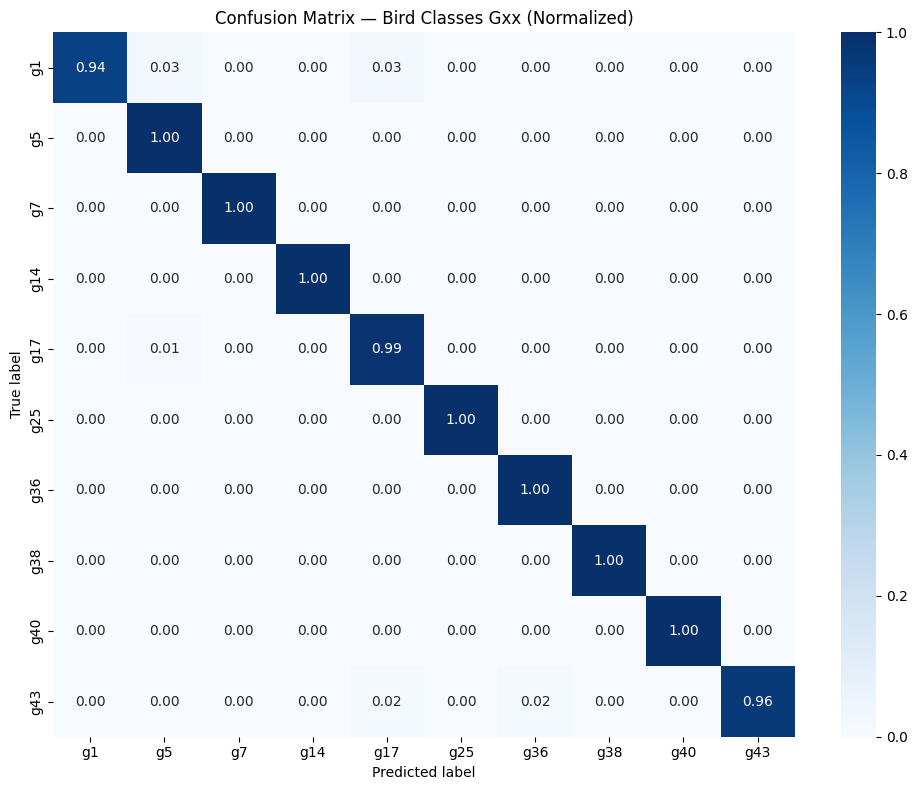

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(sub_norm, annot=True, fmt='.2f',
            xticklabels=bird_classes,
            yticklabels=bird_classes,
            cmap='Blues', vmin=0, vmax=1)
plt.title('Confusion Matrix — Bird Classes Gxx (Normalized)')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.savefig('confusion_birds_v1.png', dpi=150)
plt.show()

In [ ]:
import shutil
from pathlib import Path

In [ ]:
DRIVE_SAVE = '/content/drive/MyDrive/SphinxEyes_weights/'
Path(DRIVE_SAVE).mkdir(parents=True, exist_ok=True)

In [ ]:
for weight in ['best.pt', 'last.pt']:
    src = f'SphinxEyes/v1/weights/{weight}'
    dst = f'{DRIVE_SAVE}v1_{weight}'
    if Path(src).exists():
        shutil.copy2(src, dst)
        mb = Path(dst).stat().st_size / 1e6
        print(f'✓ {dst} ({mb:.1f} MB)')
    else:
        print(f'✗ Not found: {src}')

✗ Not found: SphinxEyes/v1/weights/best.pt
✗ Not found: SphinxEyes/v1/weights/last.pt


In [ ]:
shutil.copytree(f'{BASE_FOLDER}/sphinx_eyes_v1',
                Path(DRIVE_SAVE) / 'v1_results',
                dirs_exist_ok=True)
print(f'\n✓ All saved to Drive: {DRIVE_SAVE}')


✓ All saved to Drive: /content/drive/MyDrive/SphinxEyes_weights/


In [ ]:
wandb.finish()
print('✓ W&B closed')

✓ W&B closed


In [ ]:
TEST_IMG_DIR = '/content/test_imgs'

# Check if the directory exists
if not os.path.exists(TEST_IMG_DIR):
    print(f'Error: Directory {TEST_IMG_DIR} does not exist.')
    print('Please create the directory and place your test images inside.')
else:
    print(f'Running predictions on images in {TEST_IMG_DIR}...')
    # Run inference with the best model
    results = best_model.predict(
        source  = TEST_IMG_DIR,
        imgsz   = 640,
        save    = True,          # Save predicted images with bounding boxes
        project = BASE_FOLDER,   # Save results to the Sphinx_Project folder on Drive
        name    = 'test_predictions_640px' # A specific name for this prediction run
    )
    print(f'Predictions saved to: {BASE_FOLDER}/test_predictions_640px')

Running predictions on images in /content/test_imgs...

image 1/7 /content/test_imgs/escritura-antiguo-egipto.jpg: 448x640 1 cartouche, 87.8ms
image 2/7 /content/test_imgs/fghjk.jpeg: 288x640 1 cartouche, 89.0ms
image 3/7 /content/test_imgs/fghjk.webp: 448x640 (no detections), 17.8ms
image 4/7 /content/test_imgs/glyphs.jpeg: 640x640 1 unknown, 17.3ms
image 5/7 /content/test_imgs/images (3).jpeg: 448x640 1 g40, 17.9ms
image 6/7 /content/test_imgs/tyuytrty.jpg: 640x640 1 l2, 17.7ms
image 7/7 /content/test_imgs/tyuytyu.jpeg: 448x640 1 g40, 18.0ms
Speed: 2.2ms preprocess, 37.9ms inference, 1.3ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/drive/MyDrive/Sphinx_Project/test_predictions_640px
Predictions saved to: /content/drive/MyDrive/Sphinx_Project/test_predictions_640px


## Double Imports

In [ ]:
from ultralytics import YOLO
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
model = YOLO('/content/drive/MyDrive/SphinxEyes_weights/v1_results/weights/best.pt')

In [ ]:
TEST_DIR = '/content/test_imgs/'
images   = list(Path(TEST_DIR).glob('*'))
images   = [f for f in images if f.suffix.lower()
            in {'.jpg','.jpeg','.png','.webp'}]
print(f'Found {len(images)} test images')

Found 6 test images


## Test best.pt model with new images

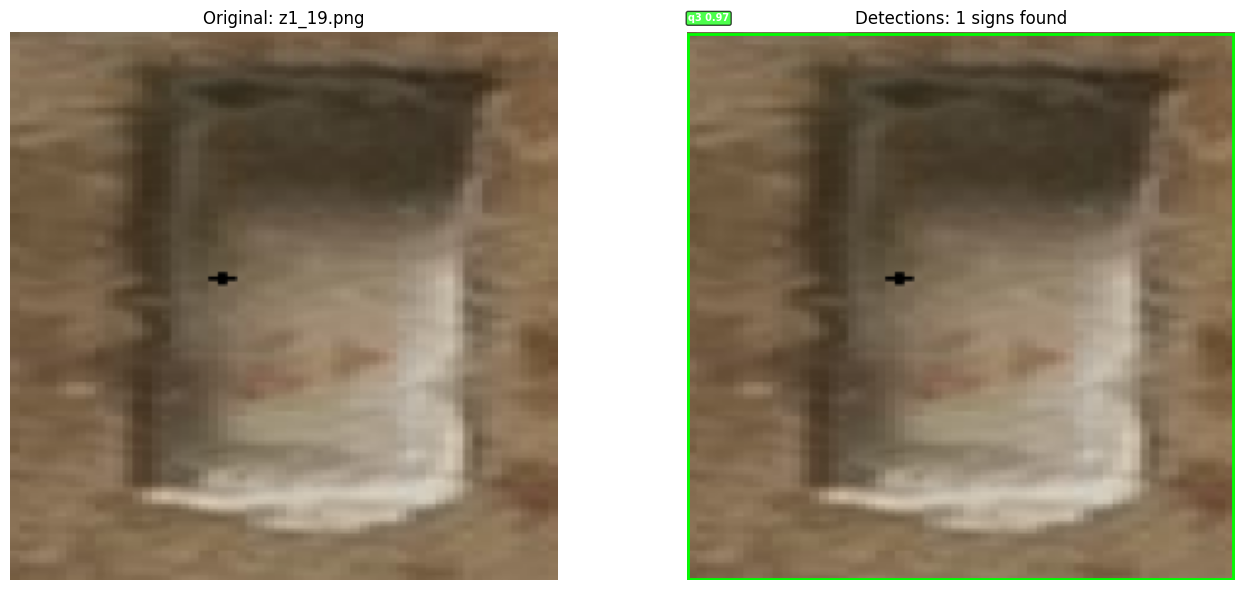


Image: z1_19.png
Signs detected: 1
Sign        Confidence
-------------------------
q3              0.9659  █████████ ✓



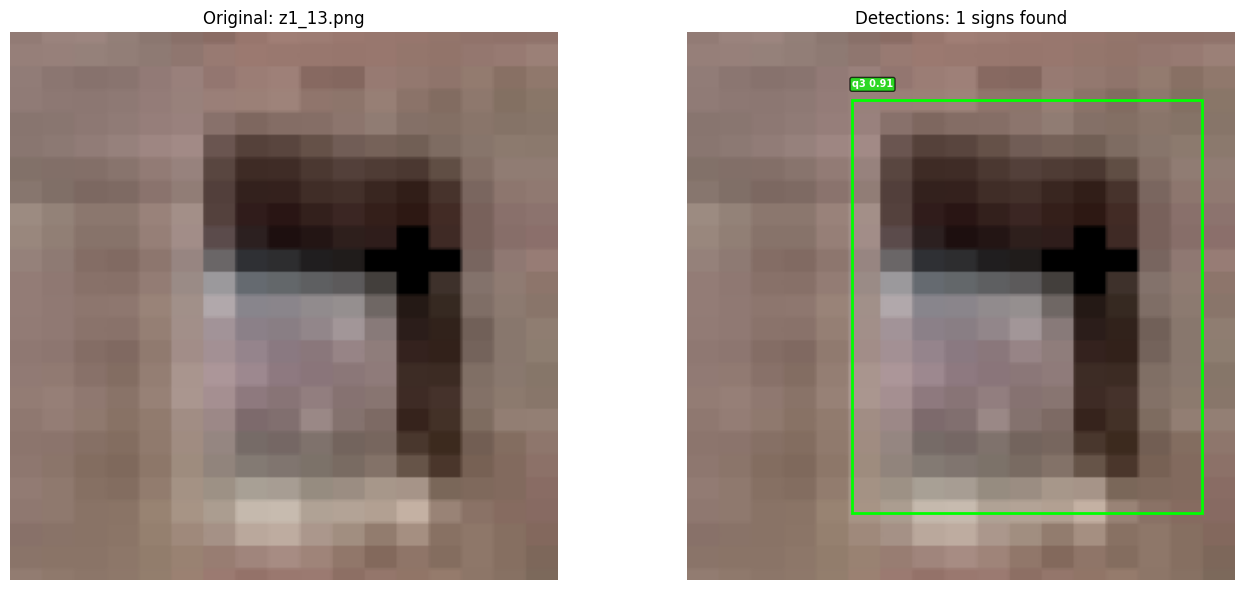


Image: z1_13.png
Signs detected: 1
Sign        Confidence
-------------------------
q3              0.9061  █████████ ✓



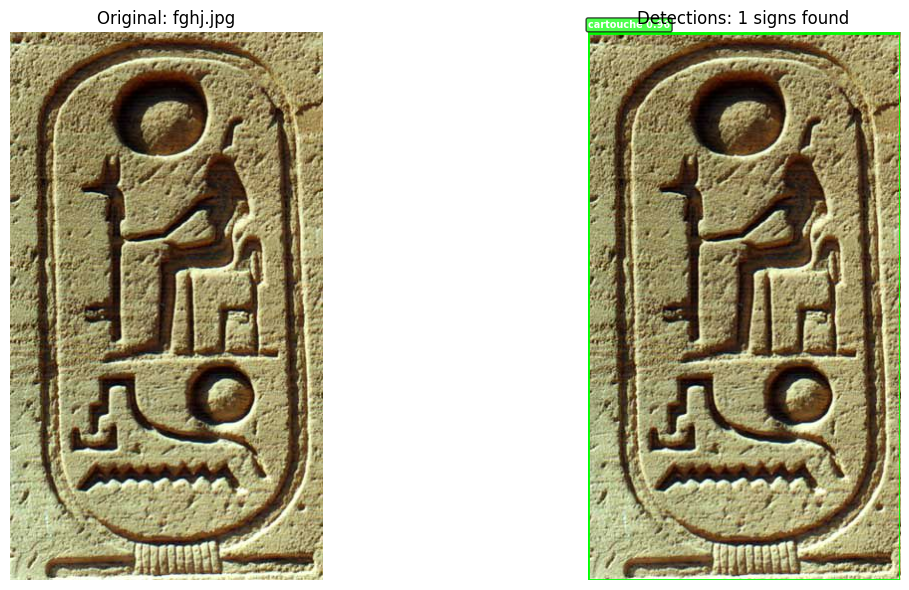


Image: fghj.jpg
Signs detected: 1
Sign        Confidence
-------------------------
cartouche       0.9573  █████████ ✓



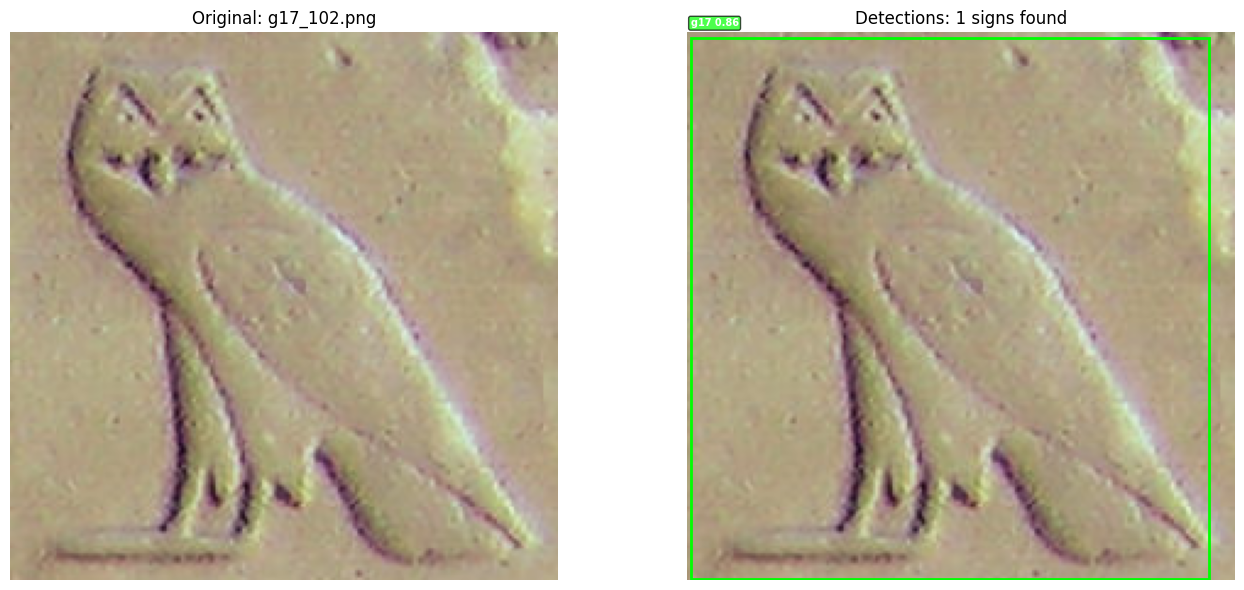


Image: g17_102.png
Signs detected: 1
Sign        Confidence
-------------------------
g17             0.8633  ████████ ✓



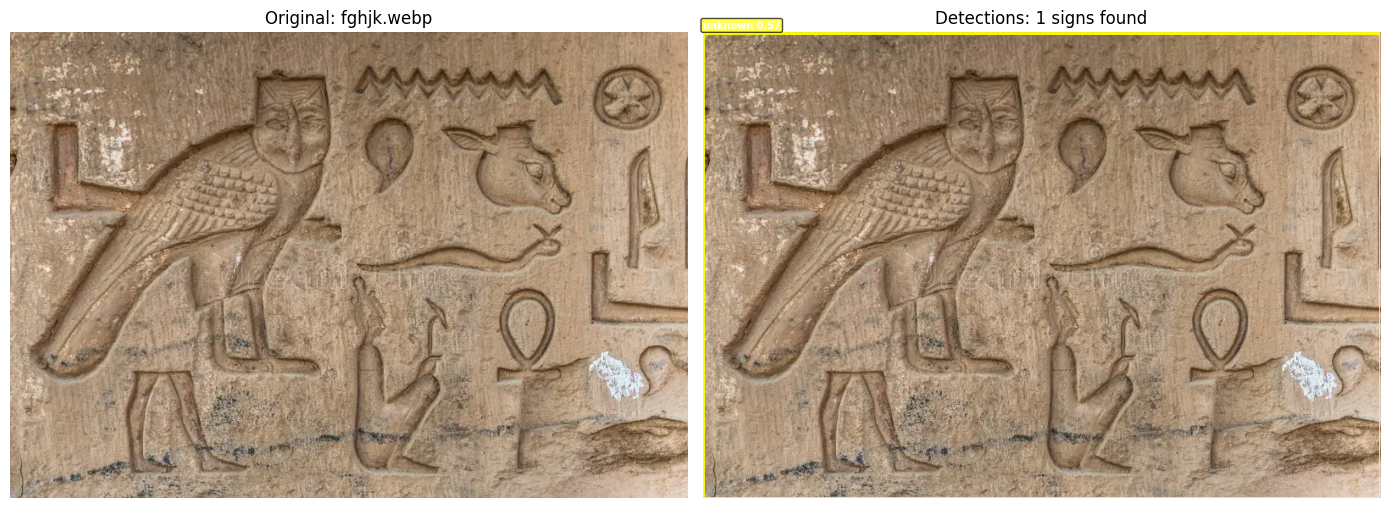


Image: fghjk.webp
Signs detected: 1
Sign        Confidence
-------------------------
unknown         0.5689  █████ ⚠



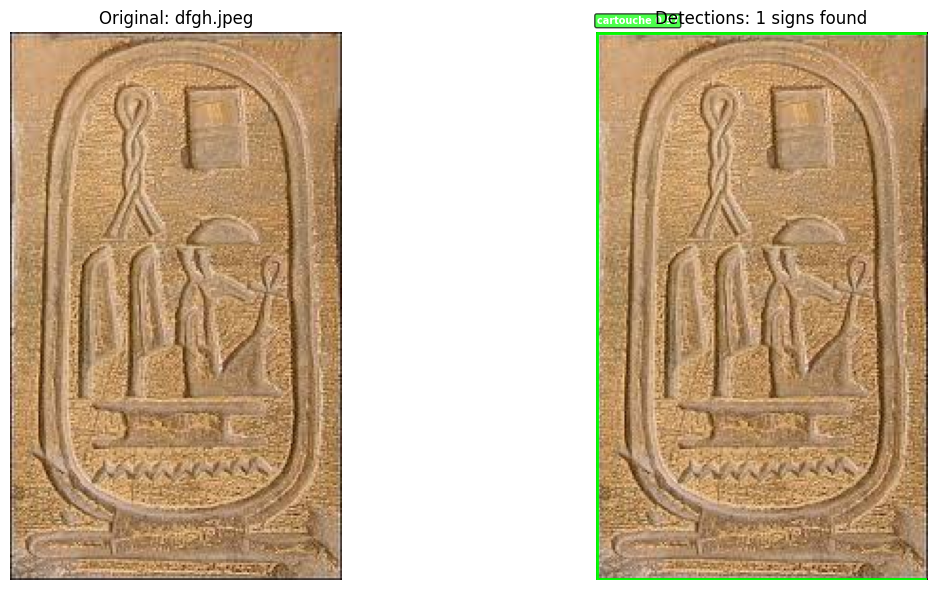


Image: dfgh.jpeg
Signs detected: 1
Sign        Confidence
-------------------------
cartouche       0.9726  █████████ ✓



In [ ]:
for img_path in images:
    results = model(
        str(img_path),
        imgsz   = 224,
        conf    = 0.25,
        iou     = 0.30,
        verbose = False
    )

    result = results[0]
    img_bgr = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Imagen original
    axes[0].imshow(img_rgb)
    axes[0].set_title(f'Original: {img_path.name}')
    axes[0].axis('off')

    # Imagen con detecciones
    axes[1].imshow(img_rgb)
    axes[1].set_title(f'Detections: {len(result.boxes)} signs found')
    axes[1].axis('off')

    detections = []
    for box in result.boxes:
        cls_id = int(box.cls[0])
        conf   = float(box.conf[0])
        name   = model.names[cls_id]
        x1, y1, x2, y2 = map(int, box.xyxy[0])

        # Color por confianza
        if conf >= 0.80:
            color = 'lime'
        elif conf >= 0.50:
            color = 'yellow'
        else:
            color = 'red'

        rect = patches.Rectangle(
            (x1, y1), x2-x1, y2-y1,
            linewidth=2, edgecolor=color, facecolor='none'
        )
        axes[1].add_patch(rect)
        axes[1].text(
            x1, y1-5, f'{name} {conf:.2f}',
            color='white', fontsize=7, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.2', facecolor=color, alpha=0.7)
        )
        detections.append((name, conf))

    plt.tight_layout()
    plt.savefig(f'/content/test_imgs/result_{img_path.stem}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    # Secuencia de signos detectados
    print(f'\n{"="*50}')
    print(f'Image: {img_path.name}')
    print(f'Signs detected: {len(detections)}')
    print(f'{"Sign":10s}  {"Confidence":>10s}')
    print('-' * 25)
    for name, conf in detections:
        bar   = '█' * int(conf * 10)
        flag  = '✓' if conf >= 0.80 else '⚠' if conf >= 0.50 else '✗'
        print(f'{name:10s}  {conf:10.4f}  {bar} {flag}')
    print(f'{"="*50}\n')

In [ ]:
TEST_DIR = '/content/test_imgs2/'
images   = list(Path(TEST_DIR).glob('*'))
images   = [f for f in images if f.suffix.lower()
            in {'.jpg','.jpeg','.png','.webp'}]
print(f'Found {len(images)} test images')

Found 3 test images


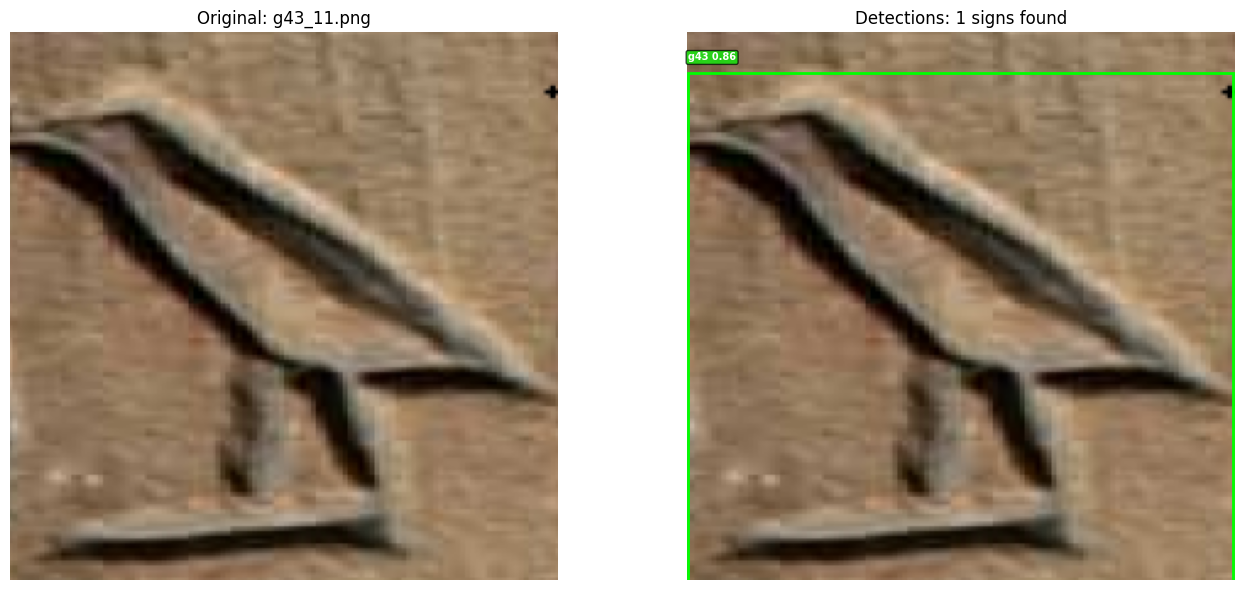


Image: g43_11.png
Signs detected: 1
Sign        Confidence
-------------------------
g43             0.8552  ████████ ✓



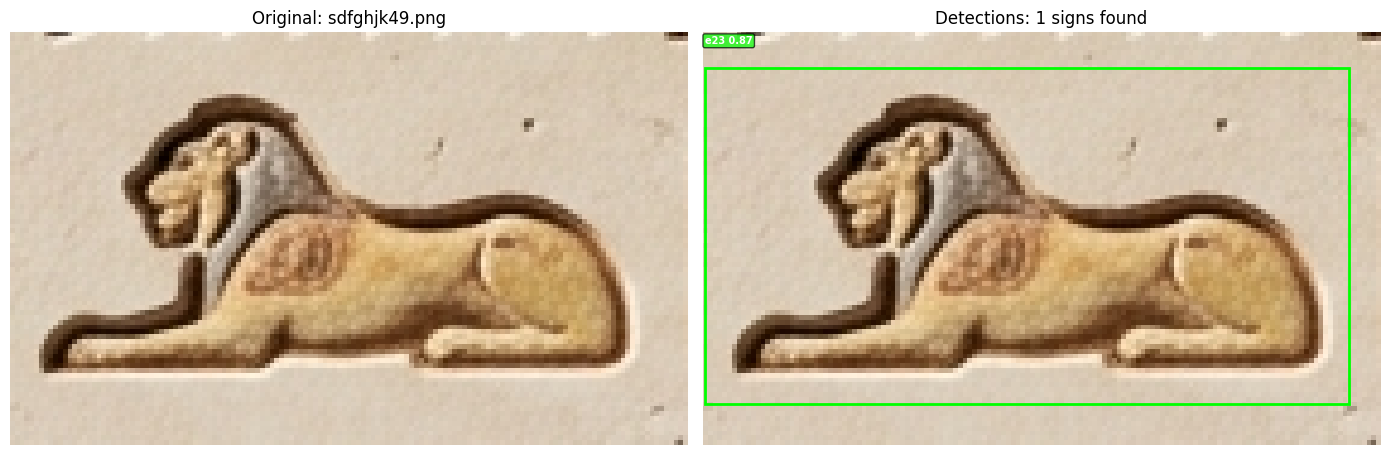


Image: sdfghjk49.png
Signs detected: 1
Sign        Confidence
-------------------------
e23             0.8712  ████████ ✓



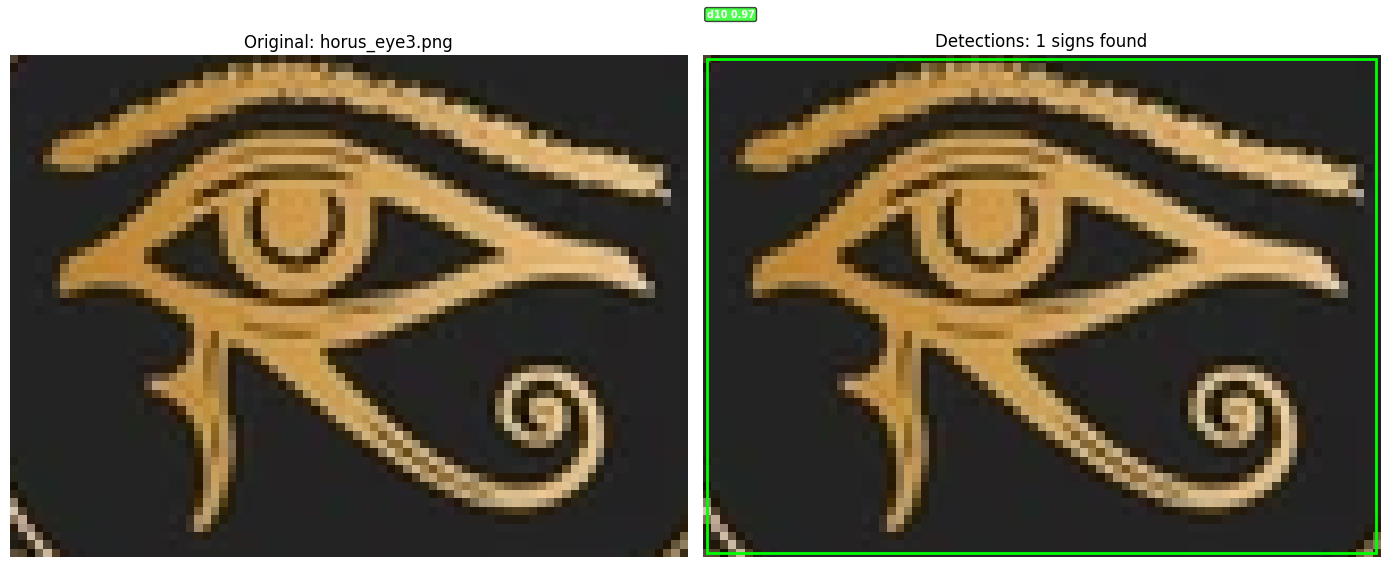


Image: horus_eye3.png
Signs detected: 1
Sign        Confidence
-------------------------
d10             0.9719  █████████ ✓



In [ ]:
for img_path in images:
    results = model(
        str(img_path),
        imgsz   = 224,
        conf    = 0.25,    # umbral de confianza
        iou     = 0.30,    # permite overlap para signos apilados
        verbose = False
    )

    result = results[0]
    img_bgr = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Imagen original
    axes[0].imshow(img_rgb)
    axes[0].set_title(f'Original: {img_path.name}')
    axes[0].axis('off')

    # Imagen con detecciones
    axes[1].imshow(img_rgb)
    axes[1].set_title(f'Detections: {len(result.boxes)} signs found')
    axes[1].axis('off')

    detections = []
    for box in result.boxes:
        cls_id = int(box.cls[0])
        conf   = float(box.conf[0])
        name   = model.names[cls_id]
        x1, y1, x2, y2 = map(int, box.xyxy[0])

        # Color por confianza
        if conf >= 0.80:
            color = 'lime'
        elif conf >= 0.50:
            color = 'yellow'
        else:
            color = 'red'

        rect = patches.Rectangle(
            (x1, y1), x2-x1, y2-y1,
            linewidth=2, edgecolor=color, facecolor='none'
        )
        axes[1].add_patch(rect)
        axes[1].text(
            x1, y1-5, f'{name} {conf:.2f}',
            color='white', fontsize=7, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.2', facecolor=color, alpha=0.7)
        )
        detections.append((name, conf))

    plt.tight_layout()
    plt.savefig(f'/content/test_imgs/result_{img_path.stem}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    # Secuencia de signos detectados
    print(f'\n{"="*50}')
    print(f'Image: {img_path.name}')
    print(f'Signs detected: {len(detections)}')
    print(f'{"Sign":10s}  {"Confidence":>10s}')
    print('-' * 25)
    for name, conf in detections:
        bar   = '█' * int(conf * 10)
        flag  = '✓' if conf >= 0.80 else '⚠' if conf >= 0.50 else '✗'
        print(f'{name:10s}  {conf:10.4f}  {bar} {flag}')
    print(f'{"="*50}\n')

Results were good enough for trainign v1 to save best.pt in order to train v2